# 02 · Quality control

Steps 11 to 14. Everything here is about **what to throw away, and why** — first cells,
then whole wells, then a check that plate position is not quietly doing the work.

| | |
|---|---|
| **Step 11** | Remove cells you cannot trust *(Part 3's memory peak)* |
| **Step 12** | Should any wells be dropped? |
| **Step 13** | Does plate position matter? |
| **Step 14** | Save the cleaned table |

Every drop is a decision. The rule for the whole chapter: **write down what you removed
and why, in the notebook, next to the number that justified it.**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import analysis, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

adata = sc.read_h5ad(H5AD_SLIM)
adata

AnnData object with n_obs × n_vars = 73354 × 2587
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme'
    uns: 'fixture_fraction', 'is_fixture', 'provenance'

## Step 11 · Remove cells you cannot trust

The feature table ships two flags from the segmentation step. `is_border_external`
marks cells touching the edge of an imaged field; `is_border_internal` marks cells on
an internal boundary between fields.

A cell cut off by the edge of the image has a truncated area, a truncated perimeter and
a mean intensity computed over only part of itself. Every one of its features is wrong
in a direction that depends on how much was cut off.

In [2]:
flags = adata.obs[["is_border_external", "is_border_internal"]]
pd.DataFrame({
    "cells": flags.sum(),
    "fraction": (flags.sum() / len(flags)).map("{:.1%}".format),
})

,cells,fraction
is_border_external,7962,10.9%
is_border_internal,788,1.1%


Before dropping them, look at *how* wrong they are — partly to justify the decision,
partly because "border cells are smaller" is the kind of claim that should be checked
rather than assumed.

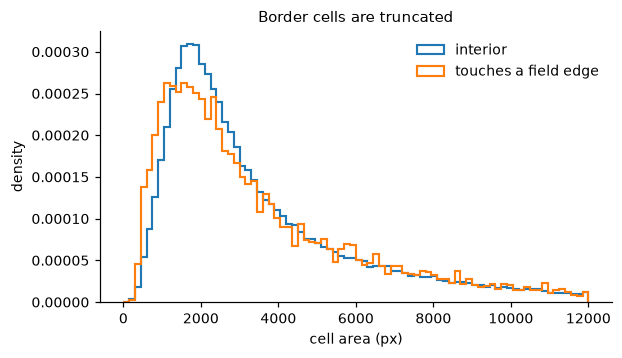

In [3]:
area_column = adata.var.index[
    (adata.var.family == "Morphology") & (adata.var.statistic == "area")
][0]
area = np.asarray(adata[:, area_column].X).ravel()

fig, ax = plt.subplots(figsize=(6, 3.2))
for is_border, label in [(False, "interior"), (True, "touches a field edge")]:
    ax.hist(area[adata.obs.is_border_external.values == is_border], bins=80,
            range=(0, 12000), histtype="step", density=True, label=label, linewidth=1.4)
ax.set(xlabel="cell area (px)", ylabel="density", title="Border cells are truncated")
ax.legend()

In [4]:
clean = adata[~adata.obs.is_border_external.values].copy()
print(f"{adata.n_obs:,} cells -> {clean.n_obs:,} "
      f"({1 - clean.n_obs / adata.n_obs:.1%} removed)")

# This line is the memory peak of the whole of Part 3: for a moment `adata` and `clean`
# both exist, roughly 1.9x the slim table. In a tight session, free the original:
#     import gc; del adata; gc.collect()

73,354 cells -> 65,392 (10.9% removed)


:::{note}
We keep the internal-border cells. They sit on a seam between two imaged fields of the
same well, where the image is still complete — the flag marks a stitching boundary, not
a truncated cell. Dropping them too is defensible; dropping them *without saying so* is
not.
:::

## Step 12 · Should any wells be dropped?

Cells are cheap to drop — there are hundreds of thousands. A **well** is one of only
224, and one of only three replicates of its condition at its timepoint. Dropping one
costs a third of the evidence for that comparison, so the bar has to be higher.

Start with the most basic thing a well can fail at: **did anything grow in it?**

In [5]:
counts = (clean.obs.groupby(["well", "timepoint_h", "condition"], observed=True)
          .size().rename("cells").reset_index())
counts["timepoint_h"] = counts["timepoint_h"].astype(int)
counts.cells.describe()[["count", "mean", "min", "50%", "max"]].round(0)

count    224.0
mean     292.0
min       43.0
50%      230.0
max      668.0
Name: cells, dtype: float64

A 14-fold range between the emptiest and fullest well. It is tempting to set a floor
here and move on. Do not — first check whether the spread means what it looks like.

In [6]:
counts.groupby("timepoint_h")["cells"].describe()[["count", "mean", "min", "50%", "max"]].round(0)

,count,mean,min,50%,max
timepoint_h,,,,,
36,56.0,133.0,102.0,130.0,166.0
48,56.0,188.0,126.0,191.0,238.0
60,56.0,347.0,187.0,352.0,476.0
84,56.0,500.0,43.0,528.0,668.0


**The count is mostly telling you the timepoint.** The cells are still dividing, so an
84-hour well holds three to four times what a 36-hour well does. A single global
threshold would delete most of the 36-hour plate for being 36 hours old.

So compare each well to **its own timepoint**.

In [7]:
counts["share"] = counts.groupby("timepoint_h")["cells"].transform(lambda s: s / s.median())
counts.nsmallest(8, "share")[["well", "timepoint_h", "condition", "cells", "share"]].round(3)

,well,timepoint_h,condition,cells,share
15,B23,84,PF-4708671,43,0.081
127,I23,84,Sapanisertib/INK128,252,0.477
94,G22,84,Sapanisertib/INK128,271,0.513
220,O20,84,Sapanisertib/INK128,272,0.515
216,O14,60,Sapanisertib/INK128,187,0.531
60,E20,84,Cycloheximide,299,0.566
8,B14,60,PBS,205,0.582
29,C21,84,MK-2206,331,0.627


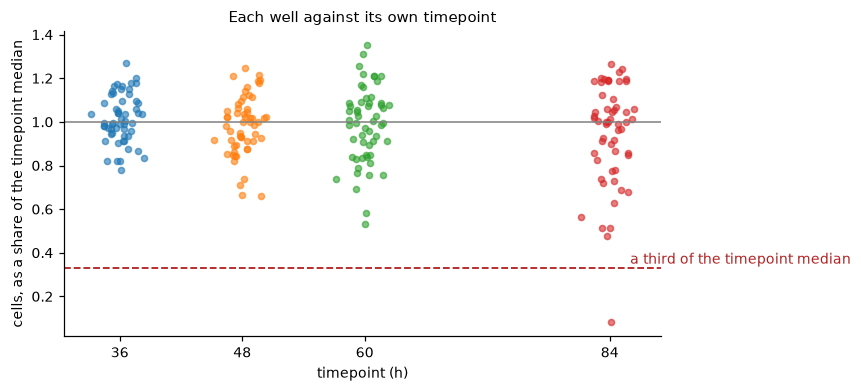

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for timepoint, block in counts.groupby("timepoint_h"):
    ax.scatter(np.full(len(block), timepoint) + np.random.default_rng(0).normal(0, 1.2, len(block)),
               block.share, s=16, alpha=0.6, label=f"{timepoint} h")
ax.axhline(1.0, color="0.5", lw=1)
ax.axhline(0.33, color="firebrick", lw=1.2, ls="--")
ax.annotate("a third of the timepoint median", (86, 0.35), fontsize=9, color="firebrick")
ax.set(xlabel="timepoint (h)", ylabel="cells, as a share of the timepoint median",
       title="Each well against its own timepoint")
ax.set_xticks([36, 48, 60, 84])

One well sits far below everything else. Look at the bottom of the list again:

**`B23` holds 9% of its timepoint's median.** The next-lowest well holds 45%. That is
not a borderline call — it fails by a factor of five against its nearest neighbour, and
there is no threshold between 10% and 45% that would treat them the same.

### The wells you must *not* drop

Look at what comes next in that list, and at which condition those wells are.

In [9]:
counts.nsmallest(6, "share").merge(
    counts[["well"]], on="well")[["well", "timepoint_h", "condition", "cells", "share"]].round(3)

,well,timepoint_h,condition,cells,share
0,B23,84,PF-4708671,43,0.081
1,I23,84,Sapanisertib/INK128,252,0.477
2,G22,84,Sapanisertib/INK128,271,0.513
3,O20,84,Sapanisertib/INK128,272,0.515
4,O14,60,Sapanisertib/INK128,187,0.531
5,E20,84,Cycloheximide,299,0.566


`I23`, `G22` and `O20` are all **Sapanisertib/INK128** — an mTOR inhibitor. mTOR
controls cell growth and division, so a well treated with it *should* contain fewer
cells. They are sparse because **the drug worked**.

:::{important}
This is the trap the step exists for. A low cell count is sometimes a failed well and
sometimes the phenotype, and the number alone cannot tell you which. Applying a
"minimum 50% of median" rule here would have silently deleted the strongest biological
effect on the plate.

Before dropping a well for being sparse, ask what was done to it.
:::

### A method that does not work here

The instinct is to flag outliers statistically — z-score each well within its own
condition and timepoint, and drop anything extreme. Try it.

In [10]:
counts["z"] = counts.groupby(["condition", "timepoint_h"], observed=True)["cells"].transform(
    lambda s: (s - s.mean()) / s.std(ddof=0)
)
counts.z.abs().nlargest(10).round(4).to_frame("|z|")

,|z|
215,1.7760
209,1.6659
120,1.5503
82,1.4142
180,1.4142
138,1.4142
195,1.4142
175,1.4142
158,1.4141
88,1.4140


Look at the values, not the ranking. Most of them are **exactly 1.4142**, and a few sit
a little higher. Neither is a coincidence.

With $n$ points, the largest possible $|z|$ computed with the population SD is
$\sqrt{n-1}$. That is a hard ceiling set by the group size alone:

In [11]:
sizes = (counts.groupby(["condition", "timepoint_h"], observed=True)
         .agg(n=("cells", "size"), worst=("z", lambda s: s.abs().max()))
         .reset_index())
pd.DataFrame({
    "wells in group": sorted(sizes.n.unique()),
    "groups": [int((sizes.n == k).sum()) for k in sorted(sizes.n.unique())],
    "ceiling sqrt(n-1)": [round(float(np.sqrt(k - 1)), 4) for k in sorted(sizes.n.unique())],
    "worst observed": [round(float(sizes.loc[sizes.n == k, "worst"].max()), 4)
                       for k in sorted(sizes.n.unique())],
}).set_index("wells in group")

,groups,ceiling sqrt(n-1),worst observed
wells in group,,,
3,68,1.4142,1.4142
5,4,2.0000,1.7760


The three-well groups — every condition except DMSO — **hit their ceiling exactly**. The
few values above 1.4142 are all DMSO, which has five wells and so a ceiling of 2.0.

So the z-score is not measuring how unusual a well is. It is measuring **how many wells
are in its group**. The most extreme of any three replicates scores 1.41 whether it is a
genuine failure or the ordinary spread of three healthy wells.

:::{warning}
**Outlier detection needs more replicates than this experiment has.** With three wells
there is no statistical test that distinguishes a bad well from an unlucky one. You are
left with what the design gives you: an absolute criterion, applied consistently, and
stated out loud.
:::

### A second, independent check: staining level

Cell count says whether anything grew. It says nothing about whether the staining
worked. Median DAPI per well is an independent readout — the same stain, on every
nucleus, in every well.

  range 0.42 to 1.28 of the timepoint median


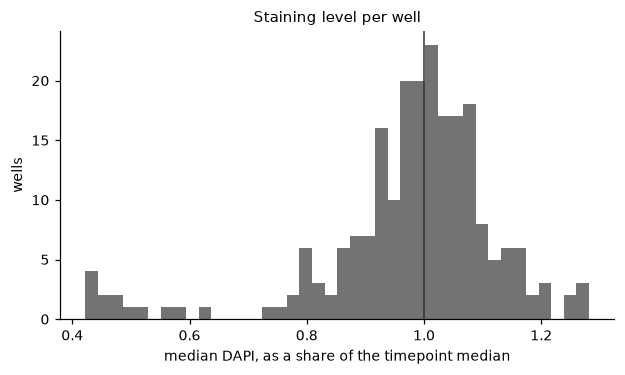

In [12]:
dapi_column = clean.var.index[
    (clean.var.channel == "DAPI") & (clean.var.statistic == "mean_intensity")
    & (clean.var["round"] == 0)
][0]
dapi = pd.DataFrame({
    "well": clean.obs.well.astype(str).values,
    "timepoint_h": clean.obs.timepoint_h.astype(int).values,
    "dapi": np.asarray(clean[:, dapi_column].X).ravel(),
})
per_well = dapi.groupby(["well", "timepoint_h"], observed=True)["dapi"].median().reset_index()
per_well["share"] = per_well.groupby("timepoint_h")["dapi"].transform(lambda s: s / s.median())

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(per_well.share, bins=40, color="0.45")
ax.axvline(1.0, color="0.2", lw=1)
ax.set(xlabel="median DAPI, as a share of the timepoint median", ylabel="wells",
       title="Staining level per well")
print(f"  range {per_well.share.min():.2f} to {per_well.share.max():.2f} of the timepoint median")

A roughly threefold spread, with no separated tail — no well failed to stain. This is a
check that comes back negative, and that is a perfectly good outcome: you now know that
staining variation is not driving anything you find later.

### The decision

In [13]:
worst = counts.nsmallest(2, "share")
DROPPED_WELLS = [worst.iloc[0].well]
DROP_REASON = (f"{worst.iloc[0].share:.0%} of its timepoint median cell count; "
               f"next-lowest well ({worst.iloc[1].well}) is {worst.iloc[1].share:.0%}")

before = clean.n_obs
clean = clean[~clean.obs.well.astype(str).isin(DROPPED_WELLS)].copy()
clean.uns["dropped_wells"] = {w: DROP_REASON for w in DROPPED_WELLS}

print(f"  dropped {len(DROPPED_WELLS)} well(s): {DROPPED_WELLS}")
print(f"  reason : {DROP_REASON}")
print(f"  cells  : {before:,} -> {clean.n_obs:,}")
print(f"  wells  : {clean.obs.well.nunique()} remain")

  dropped 1 well(s): ['B23']
  reason : 8% of its timepoint median cell count; next-lowest well (I23) is 48%
  cells  : 65,392 -> 65,349
  wells  : 223 remain


One well, recorded in `uns` with the number that justified it. Anyone reading this
object later can find out what was removed without reading the notebook.

## Step 13 · Does plate position matter?

Condition and plate position are confounded by design: each condition always sits in the
same rows. So a row-wise artefact would be indistinguishable from a treatment effect —
*except* in the control wells, which appear in every row at a fixed treatment. **DMSO is
the readout for plate position.**

In [14]:
marker_columns = analysis.marker_columns(clean.var)
wells = analysis.well_means(clean, marker_columns)
names = [clean.var.loc[c, "marker"] for c in marker_columns]
print(f"{len(wells)} wells x {len(marker_columns)} markers")
wells.iloc[:4, :6]

223 wells x 38 markers


,condition,timepoint,well,beta-Catenin,Foxo3a,FGFR1
0,Cycloheximide,36,E02,279.543549,54.023064,51.224110
1,Cycloheximide,36,H04,265.670563,53.931801,60.014679
2,Cycloheximide,36,J05,265.183960,51.977463,50.135132
3,Cycloheximide,48,E08,251.305649,40.142769,54.089458


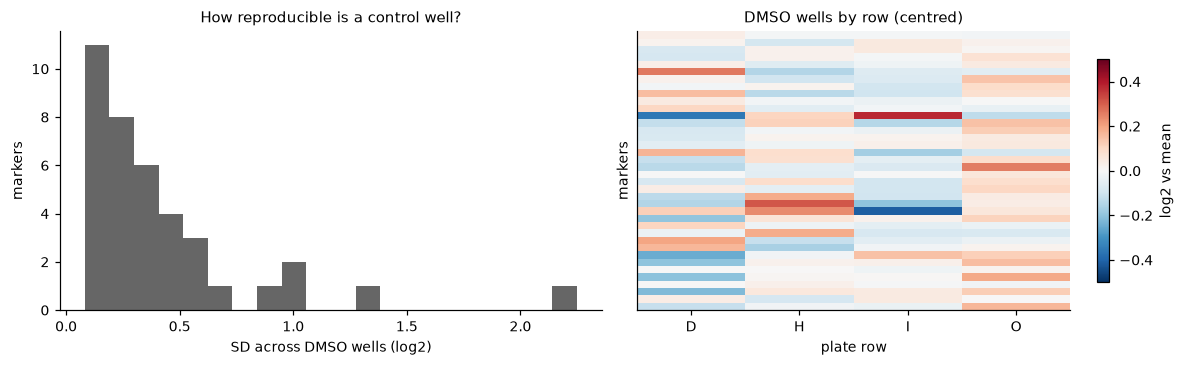

In [15]:
controls = wells[wells.condition == "DMSO"]
control_variation = np.log2(controls[names] + 1).std()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(control_variation, bins=20, color="0.4")
axes[0].set(xlabel="SD across DMSO wells (log2)", ylabel="markers",
            title="How reproducible is a control well?")
by_row = np.log2(controls.assign(row=controls.well.str[0]).set_index("row")[names] + 1
                 ).groupby(level=0).mean()
im = axes[1].imshow((by_row - by_row.mean()).T, aspect="auto", cmap="RdBu_r",
                    vmin=-0.5, vmax=0.5)
axes[1].set(xticks=range(len(by_row)), xticklabels=by_row.index, yticks=[],
            ylabel="markers", xlabel="plate row", title="DMSO wells by row (centred)")
fig.colorbar(im, ax=axes[1], shrink=0.8, label="log2 vs mean")
fig.tight_layout()

In [16]:
print(f"median control-well SD: {control_variation.median():.3f} log2 "
      f"({2 ** control_variation.median() - 1:.1%} on the linear scale)")
print(f"noisiest markers:\n{control_variation.nlargest(4).round(3).to_string()}")

median control-well SD: 0.297 log2 (22.9% on the linear scale)
noisiest markers:
GATA4         2.250
E-cadherin    1.325
p21           1.013
SOX17         0.958


That median SD is the **yardstick** for the rest of Part 3. An effect of 0.2 log2 is
within the noise of two control wells; an effect of 1.5 log2 is not.

The yardstick is *per marker*, not global. A few markers are far noisier than the rest —
usually the dim ones, where a small absolute difference is a large relative one. Scaling
each marker by **its own** control SD ([Step 17](03_normalisation.ipynb)) is what keeps
those from either shouting or being ignored.

## Step 14 · Save the cleaned table

In [17]:
clean.write_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"), compression="gzip")
print(f"  {clean.n_obs:,} cells x {clean.n_vars:,} features")
print(f"  {clean.obs.well.nunique()} wells, {clean.obs.condition.nunique()} conditions")
print(f"  dropped wells recorded in uns: {clean.uns['dropped_wells']}")

  65,349 cells x 2,587 features
  223 wells, 18 conditions
  dropped wells recorded in uns: {'B23': '8% of its timepoint median cell count; next-lowest well (I23) is 48%'}


### What this chapter removed

| | |
|---|---|
| border cells | ~11%, truncated by the edge of a field |
| `B23` | one well, 9% of its timepoint's cell count |
| *nothing else* | low-yield INK128 wells kept — that is the drug working |

---

## Exercises

### 1. Where does a threshold start deleting biology?

Sweep a minimum-cells threshold from 10% to 60% of the timepoint median. At each value,
how many wells would you drop, and how many of those are INK128?

:::{admonition} Solution
:class: dropdown

```python
for cut in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    hit = counts[counts.share < cut]
    ink = (hit.condition == "Sapanisertib/INK128").sum()
    print(f"  <{cut:.0%}: {len(hit):2d} wells, of which INK128: {ink}")
```

Below about 40% you only ever catch `B23`. Above it you start deleting INK128 wells, and
every one you remove weakens the very result the experiment was designed to find.

The gap between 10% and 45% is what makes this decision safe. Had `B23` sat at 40% there
would be no defensible threshold, and the honest move would be to keep everything and
note the concern.
:::

### 2. Does dropping B23 change anything?

`B23` is one well of Cnd6 (PF-4708671) at 84 h — so that comparison now rests on two
wells rather than three. Compute the mean of a few markers for Cnd6 at 84 h with and
without it. Does the answer move?

:::{admonition} Solution
:class: dropdown

The means barely shift, because `B23` contributed few cells to begin with — which is
exactly why it was dropped.

The cost is not in the mean, it is in the **replication**: that comparison now has
n = 2. With two wells a Mann-Whitney test cannot return anything below 2/C(7,2) = 0.095,
so no result for Cnd6 at 84 h can reach significance at all. Dropping a well is cheap in
cells and expensive in evidence, and that is the trade to keep in mind.
:::

### 3. Is position doing anything?

The DMSO-by-row heatmap is centred, so structure would show as consistent colour down a
column. Is any row systematically different? Try the same by plate *column*.

:::{admonition} Solution
:class: dropdown

```python
by_col = (np.log2(controls.assign(col=controls.well.str[1:].astype(int))
                  .set_index("col")[names] + 1).groupby(level=0).mean())
print((by_col - by_col.mean()).abs().mean(axis=1).round(3))
```

Plate **column** is confounded with timepoint here — columns 2–5 are all 36 h — so a
column-wise difference is expected and is not an artefact. Row is the axis that carries
no design meaning, which is why it is the one worth checking.
:::

---

**Next:** [03 · Normalisation](03_normalisation.ipynb) — making the numbers comparable.